# scEve model training

In [1]:
# Python packages
import warnings
warnings.simplefilter('ignore')

import scanpy as sc
import scparadise
import muon as mu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sc.set_figure_params(dpi = 120)

## Recommendations about training dataset 
We recommend the shifted logarithm data normalization method for gene expression data: <br>

```python
sc.pp.normalize_total(adata, target_sum=None)
sc.pp.log1p(adata)
```
However, you can use any other method of gene expression data normalization (use the same normalization method for the test dataset).

The training dataset should contain all genes that you want to use for model training in `mdata_train.mod['rna'].X`.

We recommend removing all non-marker genes from `mdata_train.mod['rna'].X` (removing such useless genes may improve performance and model quality metrics).

To demonstrate scEve model training and evaluation, we used eight samples from a [CITE-seq 3' PBMC dataset](https://www.cell.com/cell/fulltext/S0092-8674(21)00583-3?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0092867421005833%3Fshowall%3Dtrue). <br>
The data was normalized using the shifted logarithm algorithm, and genes were pre-sorted for model training.

In [2]:
# Download data from figshare
# You can use wget, or download the file in a browser by copying and pasting the link into a new tab.
link = 'https://figshare.com/ndownloader/files/51749906'

In [3]:
# Load prepared for training anndata object
mdata = mu.read_h5mu('mdata_pbmc.h5mu')

In [4]:
# Create mdata_train dataset (we used 4 samples for training model)
mdata_train = mdata[mdata.obs['orig.ident'].isin(['P2_0', 'P3_0', 'P4_0', 'P5_0', 'P6_0', 'P7_0', 'P8_0'])].copy()
# Create mdata_test dataset (we used 1 sample for test model quality)
mdata_test = mdata[mdata.obs['orig.ident'].isin(['P1_0'])].copy()

In [5]:
# Extract RNA expression data from mdata_test for future predictions
adata_test_rna = mdata_test.mod['rna']

## Default scEve model training

In [6]:
# Train default scEve model using mdata_train dataset
scparadise.sceve.train(
    mdata_train, 
    path = '',
    first_modality_name = 'rna',
    second_modality_name = 'adt',
    detailed_annotation = 'celltype_l3',
    model_name = 'model_scEve',
    epochs = 200,
    eval_metric = ['rmse']
)

Device: cuda
Task: Predict 'adt' from 'rna'
Number of first modality features: 635
Number of second modality features: 224

Dataset split:
Train dataset contains: 37359 cells, it is 80.0 % of input dataset
Validation dataset contains: 9340 cells, it is 20.0 % of input dataset


Training scEve model:  22%|████               | 43/200 [03:35<13:07,  5.02s/it]

Early stopping triggered! Best score: 0.3039
Training completed!
Model saved to model_scEve


## Check model quality

In [7]:
# Predict surface proteins using scEve model
mdata_pred = scparadise.sceve.predict(
    adata_test_rna, 
    path_model = 'model_scEve',
    return_mdata = True # default
)

Feature prediction using the 2nd version of the scEve model
scEve model loaded from model_scEve
Feature alignment:
Model features: 635
New data features: 635
Matched features: 635 (100.0%)


Predicting: 100%|█████████████████████████████| 25/25 [00:00<00:00, 475.21it/s]


In [8]:
# Add umap coordinates
mdata_pred.obsm['X_umap'] = adata_test_rna.obsm['X_umap']

In [9]:
# List of proteins for visualization
proteins_observed = ['adt_CLEC12A', 'adt_CD4-1', 'adt_CD8', 'adt_IgM', 'adt_CD16']

# Create list of imputed proteins
proteins_imputed = []
for i in proteins_observed:
    i = i + '_pred'
    proteins_imputed.append(i)

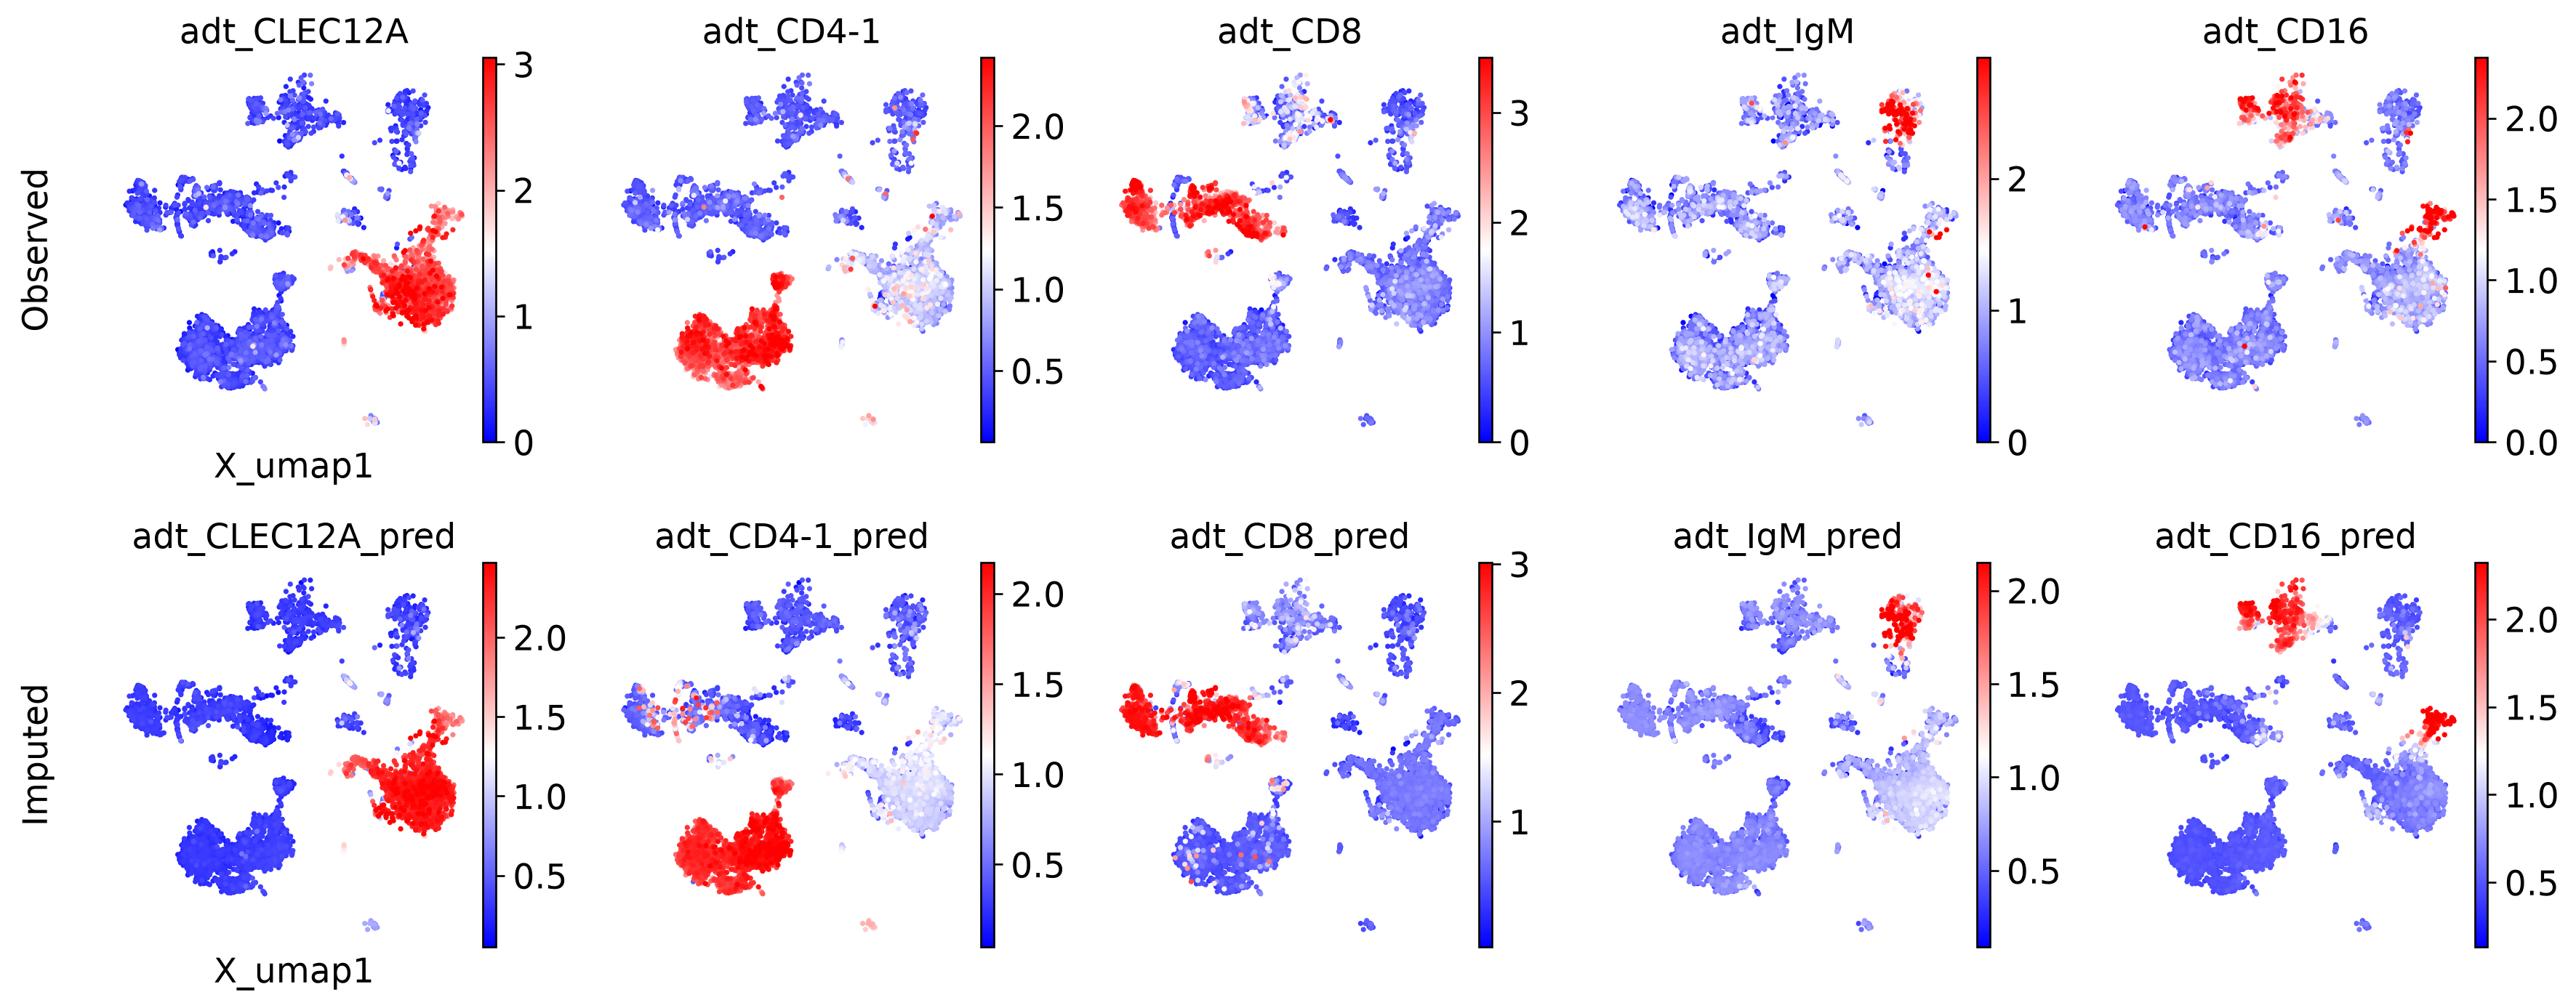

In [10]:
# Proteins visualization
proteins_dict = {
    "Observed": proteins_observed,
    "Imputed": proteins_imputed
}
# Choose a color map for protein abundance visualization
cmap = 'bwr'
# Make Axes
# Number of needed rows and columns (based on the row with the most columns)
nrow = len(proteins_dict)
ncol = max([len(vs) for vs in proteins_dict.values()])
fig, axs = plt.subplots(nrow, ncol, figsize=(3 * ncol, 3 * nrow))
# Plot expression for every marker on the corresponding Axes object
for row_idx, (prots, markers) in enumerate(proteins_dict.items()):
    col_idx = 0
    for marker in markers:
        ax = axs[row_idx, col_idx]
        if prots == 'Observed':
            mu.pl.umap(mdata_test, color=marker, cmap = cmap, ax=ax, vmax = 'p99', show=False, frameon=False)
        else:
            mu.pl.umap(mdata_pred, color=marker, cmap = cmap, ax=ax, vmax = 'p99', show=False, frameon=False)
        # Add cell type as row label - here we simply add it as ylabel of
        # the first Axes object in the row
        if col_idx == 0:
            # We disabled axis drawing in UMAP to have plots without background and border
            # so we need to re-enable axis to plot the ylabel
            ax.axis("on")
            ax.tick_params(
                top="off",
                bottom="off",
                left="off",
                right="off",
                labelleft="on",
                labelbottom="off",
            )
            ax.set_ylabel(prots + "\n", rotation=90, fontsize=14)
            ax.set(frame_on=False)
        col_idx += 1
    # Remove unused column Axes in the current row
    while col_idx < ncol:
        axs[row_idx, col_idx].remove()
        col_idx += 1
# Alignment within the Figure
fig.tight_layout()

The obtained model reliably predicts the main protein markers. However, there are proteins such as CD133, which the default model cannot predict.

In [11]:
# Check prediction results
df = scparadise.scnoah.report_reg(adata_prot = mdata_test.mod['adt'], 
                                  adata_pred_prot = mdata_pred.mod['adt'])
df

,EVS,r2_score,RMSE,MedianAE,MeanAE
score,0.281,0.235,0.328,0.201,0.248
EVS/r2_score,higher value - better prediction,,,,
RMSE/MedianAE/MeanAE,lower value - better prediction,,,,


In [13]:
# Add regression status using 5 metrics
for metric in ['RMSE', 'MeanAE', 'MedianAE', 'EVS', 'r2_score']:
    scparadise.scnoah.regres_status(adata_prot = mdata_test.mod['adt'], 
                                    adata_pred_prot = mdata_pred.mod['adt'],
                                    metric=metric)
    mdata_pred.obs[f'regres_status_{metric}'] = mdata_pred.mod['adt'].obs[f'regres_status_{metric}']

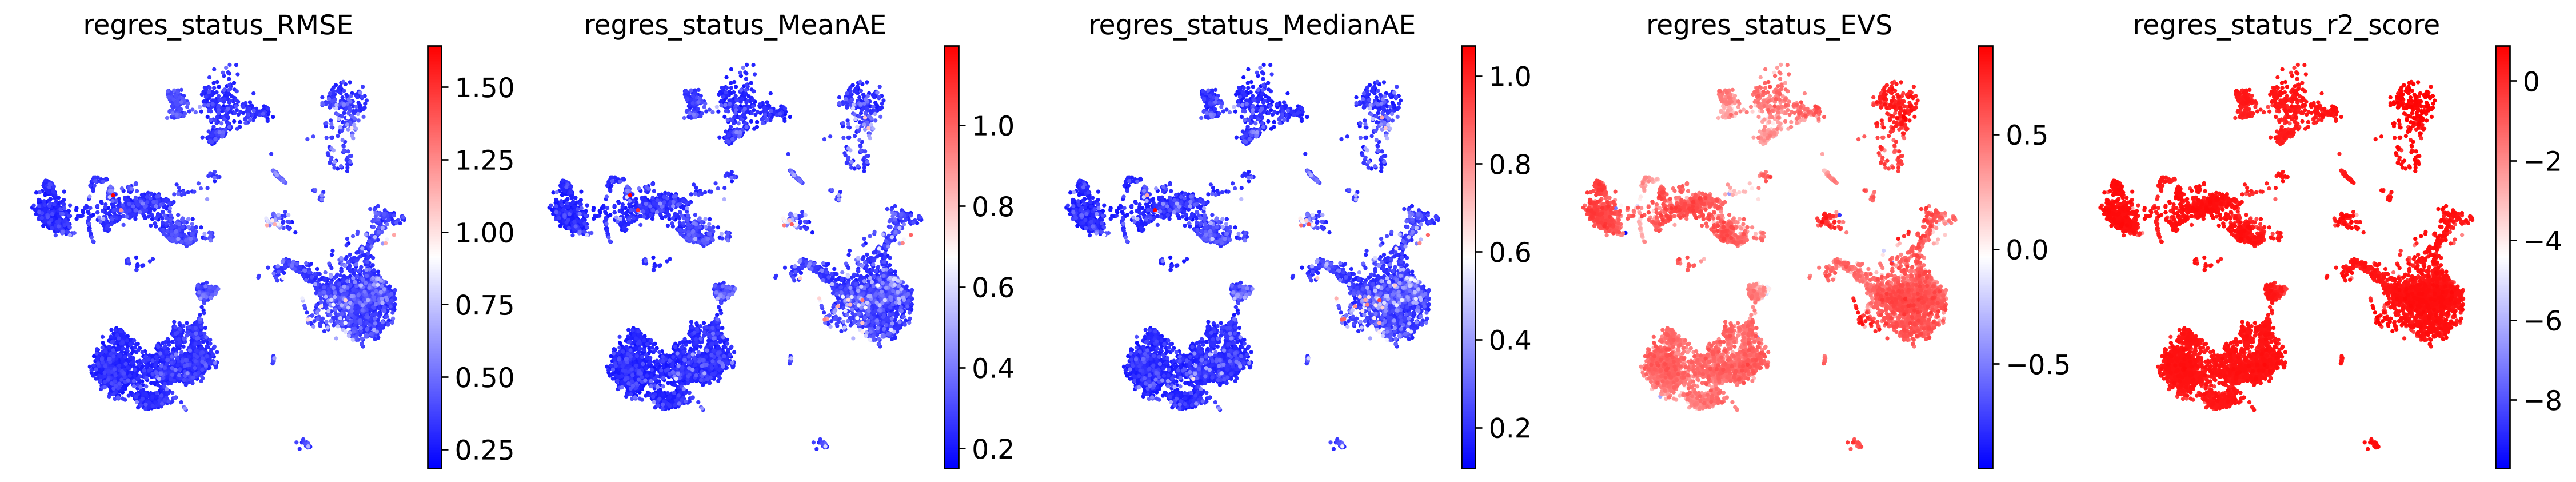

In [14]:
# Visualize metrics
mu.pl.umap(
    mdata_pred, 
    color=[
        'regres_status_RMSE', 
        'regres_status_MeanAE', 
        'regres_status_MedianAE', 
        'regres_status_EVS', 
        'regres_status_r2_score'
    ],
    frameon = False,
    cmap = 'bwr',
    ncols = 5,
    wspace = 0.15, 
    hspace = 0.1
)

Based on a per cell type regression metrics score, it is possible to draw conclusions about the uniformity of protein prediction across different cell types in the dataset.

In [16]:
# Find correlations between imputed and observed proteins
df_corr = pd.DataFrame(columns=['Pearson coef', 'p-value'])
for i in mdata_test.mod['adt'].var_names.tolist():
    person_coef = scparadise.scnoah.pearson_coef(
        adata = mdata_test.mod['adt'], 
        adata_pred = mdata_pred.mod['adt'],
        feature = i,
        feature_pred = i + '_pred',
        print_res = False
    )
    df_corr.loc[i] = [person_coef['Pearson coefficient'], person_coef['p-value']]
df_corr['p-value'] = df_corr['p-value'].astype('float64')
df_corr.sort_values('Pearson coef', ascending=False).head(5)
# p value = 0 means p-value < 0.0005

,Pearson coef,p-value
adt_CLEC12A,0.963,0.0
adt_CD64,0.943,0.0
adt_CD11b-2,0.927,0.0
adt_CD8a,0.921,0.0
adt_CD4-1,0.919,0.0


In [17]:
# Find highly correlated protein 'Pearson coef' > 0.5
df_high_corr = df_corr[df_corr['Pearson coef'] >= 0.5].copy()
print('Number of proteins with Pearson coefficient >= 0.5:', len(df_high_corr))
df_high_corr.sort_values(by = 'Pearson coef', ascending=False).head(5)
# p value = 0 means p-value < 0.0005

Number of proteins with Pearson coefficient >= 0.5: 107


,Pearson coef,p-value
adt_CLEC12A,0.963,0.0
adt_CD64,0.943,0.0
adt_CD11b-2,0.927,0.0
adt_CD8a,0.921,0.0
adt_CD4-1,0.919,0.0


In [18]:
# Save mdata with imputed proteins
mdata_pred.write_h5mu('mdata_pred_untuned.h5mu')

## Hyperparameters tuning

In [19]:
scparadise.sceve.hyperparameter_tuning(
    mdata_train, 
    path = '',
    first_modality_name = 'rna',
    second_modality_name = 'adt',
    detailed_annotation = 'celltype_l3',
    random_state = 42,
    model_name = 'model_scEve_tuning',
    eval_metric = 'rmse'
)

Device: cuda
Task: Predict 'adt' from 'rna'
Start model optimization using optuna...


[I 2026-09-03 10:37:57,873] A new study created in RDB with name: study


Fold 1 finished with rmse value = 0.305239
Fold 2 finished with rmse value = 0.305161
Fold 3 finished with rmse value = 0.302352
Fold 4 finished with rmse value = 0.303180
Fold 5 finished with rmse value = 0.302680


[I 2026-09-03 10:50:38,154] Trial 0 finished with value: 0.30372245270194725 and parameters: {'nc': 4, 'nb': 4, 'nh': 8, 'ed_nh_ratio': 32, 'ff_hd': 512, 'regressor_hd': 512, 'dropout': 0.1, 'lr': 0.0001, 'weight_decay': 0.0001, 'batch_size': 128, 'patience': 10, 'epochs': 200, 'use_augmentation': True, 'aug_probability': 0.5, 'prob': 0.15, 'noise_std': 0.1, 'dropout_aug': 0.1, 'alpha': 0.2}. Best is trial 0 with value: 0.30372245270194725.


Fold 1 finished with rmse value = 0.306941
Fold 2 finished with rmse value = 0.306451
Fold 3 finished with rmse value = 0.303622
Fold 4 finished with rmse value = 0.304643
Fold 5 finished with rmse value = 0.304347


...

[I 2026-09-05 04:59:40,883] Trial 98 pruned. 


Fold 1 finished with rmse value = 0.304305


[I 2026-09-05 05:03:11,291] Trial 99 pruned. 


Best value (rmse) = 0.3007628517181855
Best params saved to: model_scEve_tuning/best_params.txt


{'nc': 14,
 'nb': 7,
 'nh': 14,
 'ed_nh_ratio': 20,
 'ff_hd': 256,
 'regressor_hd': 640,
 'dropout': 0.06828309471373599,
 'lr': 0.0011039745179749379,
 'weight_decay': 1.6203555613578371e-06,
 'batch_size': 64,
 'patience': 30,
 'epochs': 55,
 'use_augmentation': False,
 'aug_probability': 0.4182094561013929,
 'prob': 0.344076504108704,
 'noise_std': 0.3763694706537752,
 'dropout_aug': 0.21137611594064803,
 'alpha': 0.2131686709295353}

In [20]:
# Train sceve model using mdata_train dataset
scparadise.sceve.train_tuned(
    mdata_train, 
    path = '',
    path_tuned='model_scEve_tuning',
    model_name = 'model_scEve_hp_tuned',
    first_modality_name = 'rna',
    second_modality_name = 'adt',
    detailed_annotation = 'celltype_l3',
    eval_metric=['rmse']
)

Successfully loaded tuned hyperparameters!
Device: cuda
Task: Predict 'adt' from 'rna'
Number of first modality features: 635
Number of second modality features: 224

Dataset split:
Train dataset contains: 37359 cells, it is 80.0 % of input dataset
Validation dataset contains: 9340 cells, it is 20.0 % of input dataset


Training scEve model: 100%|████████████████████| 55/55 [11:50<00:00, 12.93s/it]

Training completed!
Model saved to model_scEve_hp_tuned


## Check tuned model quality

In [21]:
# Predict surface proteins using tuned scEve model
mdata_pred = scparadise.sceve.predict(
    adata_test_rna, 
    path_model = 'model_scEve_hp_tuned',
    return_mdata = True # default value
)

Feature prediction using the 2nd version of the scEve model
scEve model loaded from model_scEve_hp_tuned
Feature alignment:
Model features: 635
New data features: 635
Matched features: 635 (100.0%)


Predicting: 100%|██████████████████████████████| 25/25 [00:00<00:00, 62.19it/s]


In [22]:
# Add umap coordinates
mdata_pred.obsm['X_umap'] = adata_test_rna.obsm['X_umap']

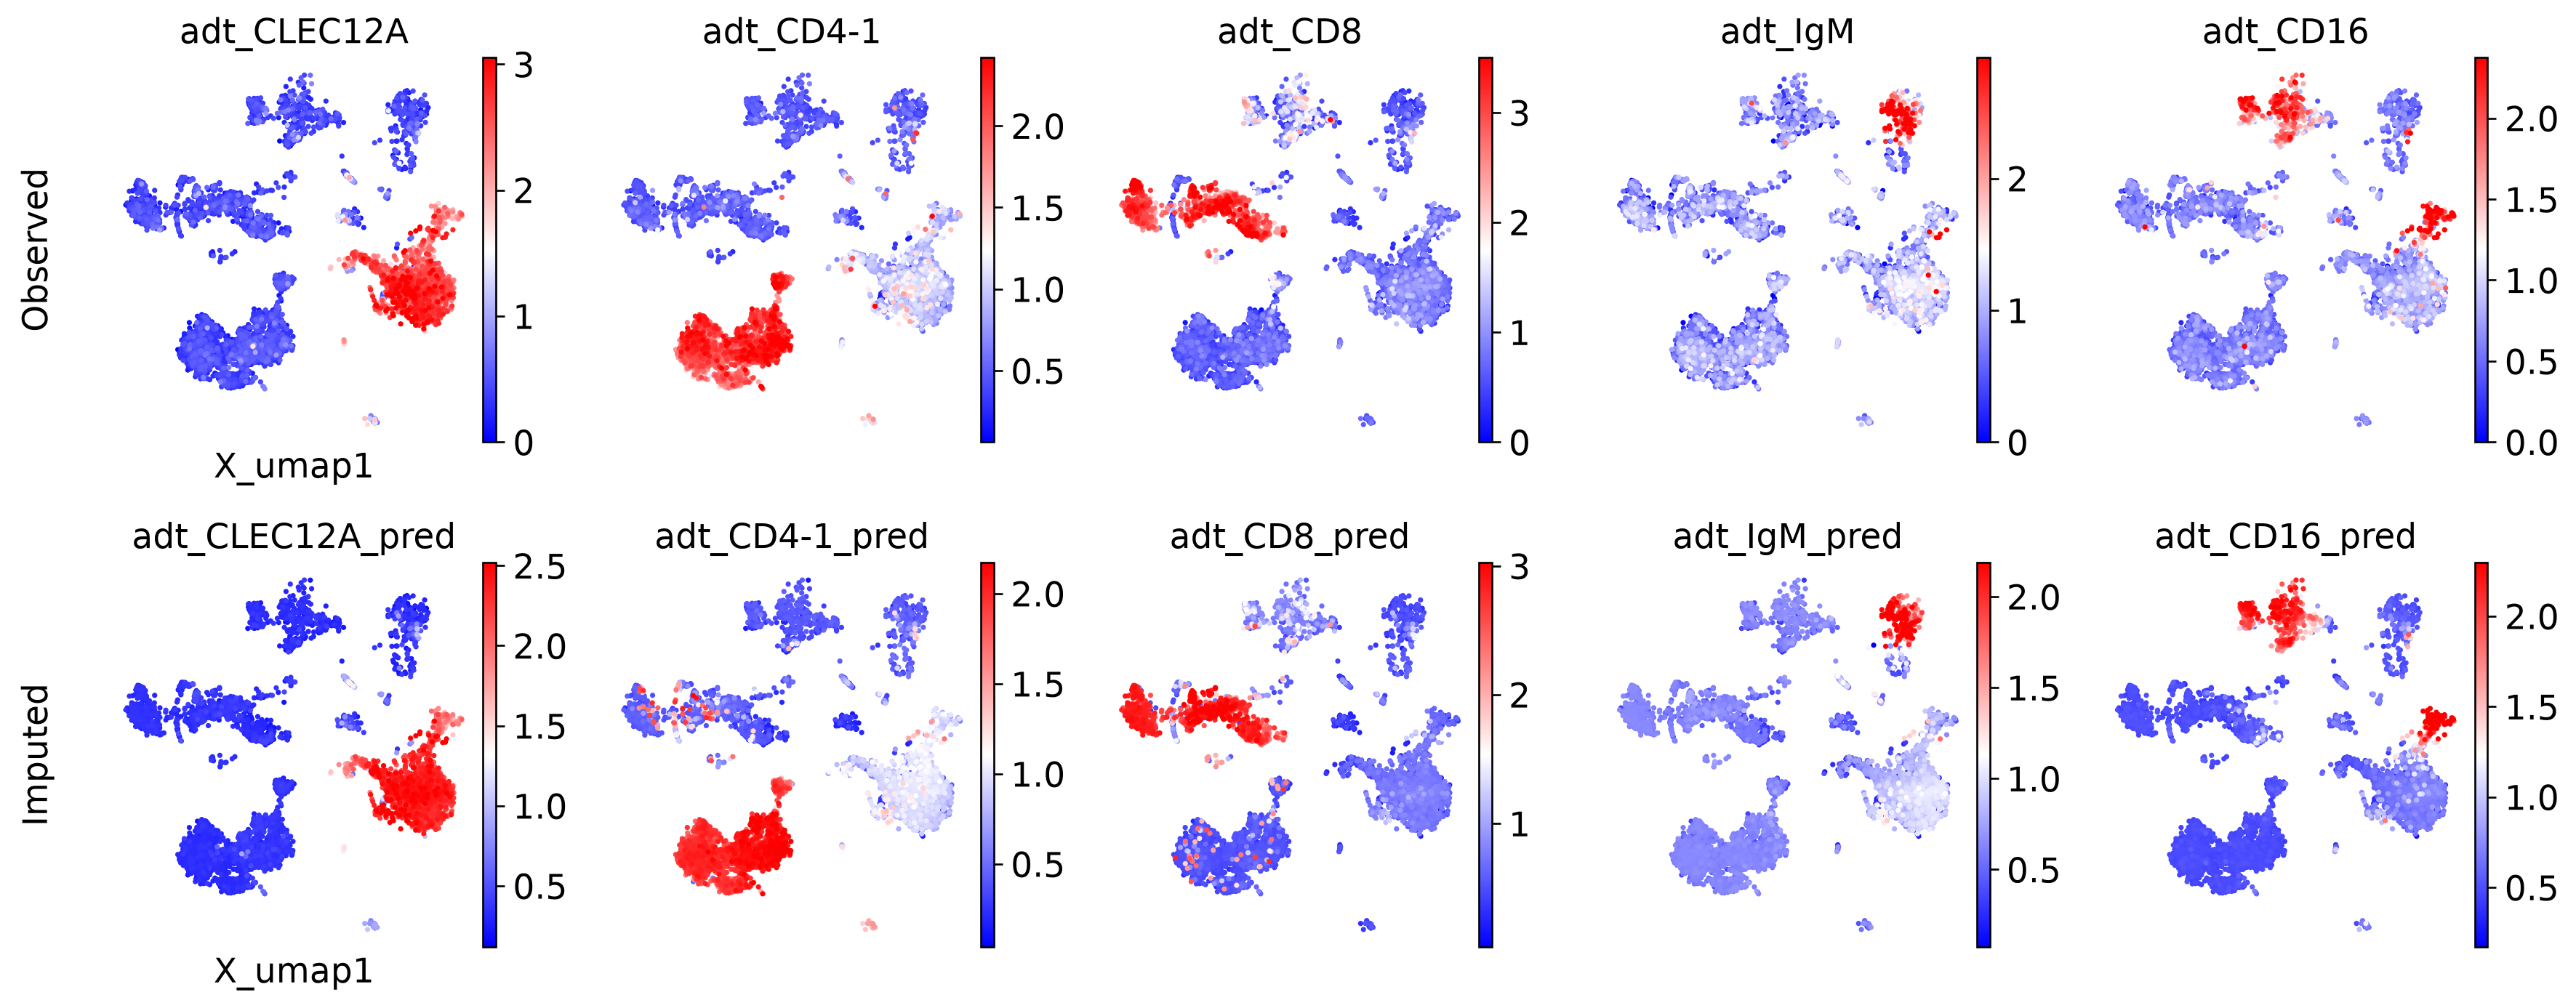

In [23]:
# Proteins visualization
proteins_dict = {
    "Observed": proteins_observed,
    "Imputed": proteins_imputed
}
# Choose a color map for protein abundance visualization
cmap = 'bwr'
# Make Axes
# Number of needed rows and columns (based on the row with the most columns)
nrow = len(proteins_dict)
ncol = max([len(vs) for vs in proteins_dict.values()])
fig, axs = plt.subplots(nrow, ncol, figsize=(3 * ncol, 3 * nrow))
# Plot expression for every marker on the corresponding Axes object
for row_idx, (prots, markers) in enumerate(proteins_dict.items()):
    col_idx = 0
    for marker in markers:
        ax = axs[row_idx, col_idx]
        if prots == 'Observed':
            mu.pl.umap(mdata_test, color=marker, cmap = cmap, ax=ax, vmax = 'p99', show=False, frameon=False)
        else:
            mu.pl.umap(mdata_pred, color=marker, cmap = cmap, ax=ax, vmax = 'p99', show=False, frameon=False)
        # Add cell type as row label - here we simply add it as ylabel of
        # the first Axes object in the row
        if col_idx == 0:
            # We disabled axis drawing in UMAP to have plots without background and border
            # so we need to re-enable axis to plot the ylabel
            ax.axis("on")
            ax.tick_params(
                top="off",
                bottom="off",
                left="off",
                right="off",
                labelleft="on",
                labelbottom="off",
            )
            ax.set_ylabel(prots + "\n", rotation=90, fontsize=14)
            ax.set(frame_on=False)
        col_idx += 1
    # Remove unused column Axes in the current row
    while col_idx < ncol:
        axs[row_idx, col_idx].remove()
        col_idx += 1
# Alignment within the Figure
fig.tight_layout()

In [24]:
# Check prediction results
df_hp_tuned = scparadise.scnoah.report_reg(
    adata_prot = mdata_test.mod['adt'], 
    adata_pred_prot = mdata_pred.mod['adt']
)
df_hp_tuned

,EVS,r2_score,RMSE,MedianAE,MeanAE
score,0.3,0.266,0.322,0.197,0.244
EVS/r2_score,higher value - better prediction,,,,
RMSE/MedianAE/MeanAE,lower value - better prediction,,,,


In [25]:
# Compare prediction results
# 'untuned' row represents untuned model
# 'hp tuned' row represents tuned model
df.compare(df_hp_tuned, keep_equal=True, align_axis = 0, result_names=('untuned', 'hp tuned'))
# EVS/r2_score:	higher value - better prediction				
# RMSE/MedianAE/MeanAE:	lower value - better prediction	

EVS r2_score   RMSE MedianAE MeanAE
score untuned   0.281    0.235  0.328    0.201  0.248
      hp tuned    0.3    0.266  0.322    0.197  0.244

Hyperparameter tuning improved the performance of the scEve prediction model across all evaluated metrics. Compared with the untuned model, the tuned model achieved higher `explained variance score` (`EVS`: `0.300 vs. 0.281`) and `R2-score` (`0.266 vs. 0.235`), indicating that it explains a larger fraction of variability in the target values. At the same time, prediction errors decreased: `RMSE` declined from 0.328 to 0.322, `MedianAE` from 0.201 to 0.197, and `MeanAE` from 0.248 to 0.244.

Overall, although the absolute improvements are modest, they are consistent across both goodness-of-fit and error-based metrics. Therefore, the `hyperparameter-tuned scEve model` should be preferred for subsequent analyses and predictions.

In [27]:
# Add regression status using 5 metrics
for metric in ['RMSE', 'MeanAE', 'MedianAE', 'EVS', 'r2_score']:
    scparadise.scnoah.regres_status(
        adata_prot = mdata_test.mod['adt'], 
        adata_pred_prot = mdata_pred.mod['adt'],
        metric=metric
    )
    mdata_pred.obs[f'regres_status_{metric}'] = mdata_pred.mod['adt'].obs[f'regres_status_{metric}']

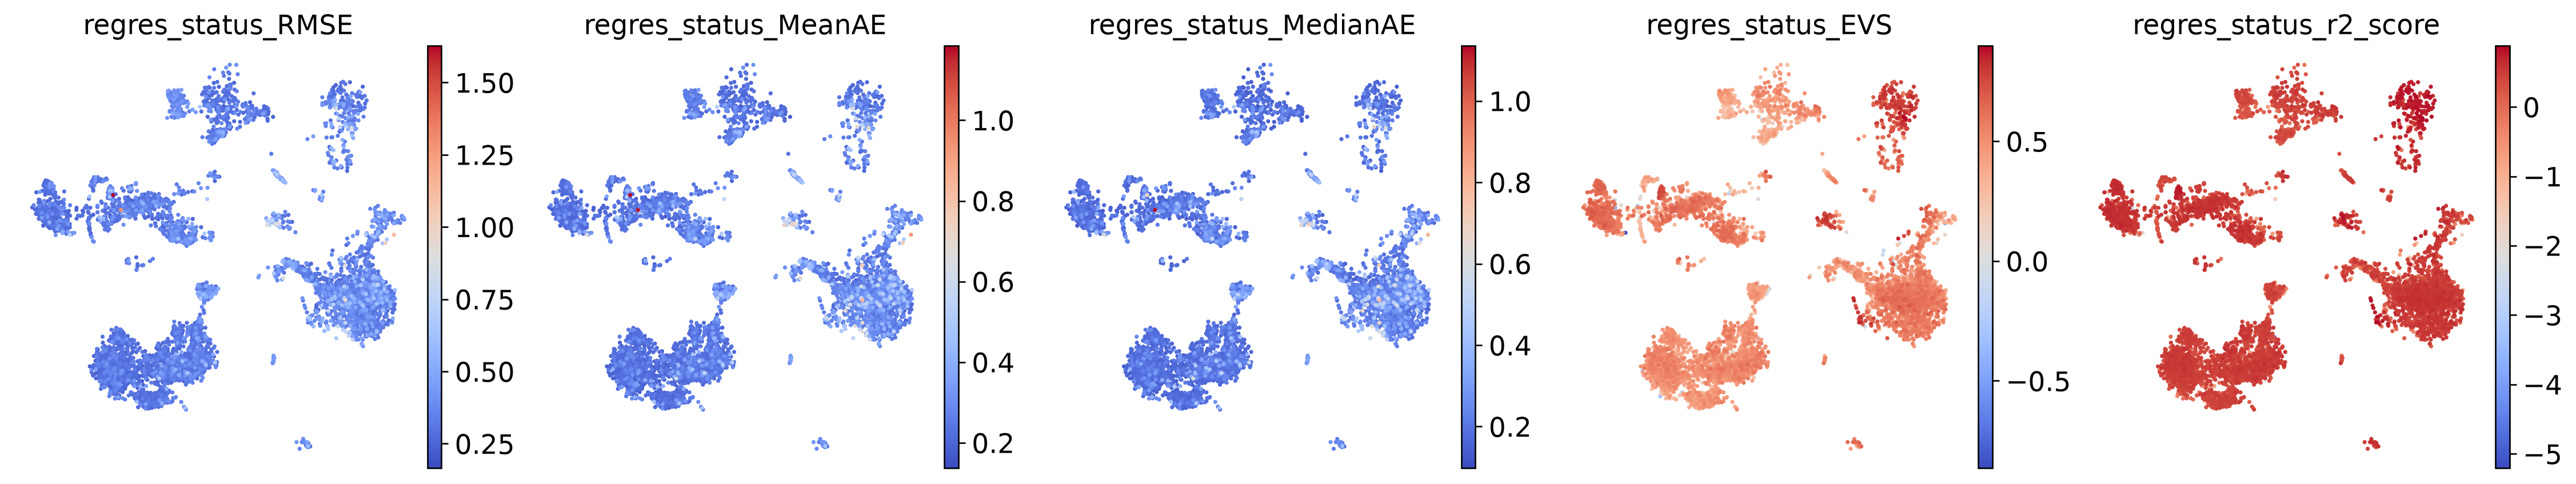

In [29]:
# Visualize observed proteins
mu.pl.umap(
    mdata_pred, 
    color=[
        'regres_status_RMSE', 
        'regres_status_MeanAE', 
        'regres_status_MedianAE', 
        'regres_status_EVS', 
        'regres_status_r2_score'
    ],
    frameon = False,
    cmap = 'coolwarm',
    ncols = 5,
    wspace = 0.15, 
    hspace = 0.1
)

Based on a per cell type regression metrics score, it is possible to draw conclusions about the uniformity of protein prediction across different cell types in the dataset.

In [30]:
# Find correlations between imputed and observed proteins
df_corr_hp_tuned = pd.DataFrame(columns=['Pearson coef', 'p-value'])
for i in mdata_test.mod['adt'].var_names.tolist():
    person_coef = scparadise.scnoah.pearson_coef(
        adata = mdata_test.mod['adt'], 
        adata_pred = mdata_pred.mod['adt'],
        feature = i,
        feature_pred = i + '_pred',
        print_res = False
    )
    df_corr_hp_tuned.loc[i] = [person_coef['Pearson coefficient'], person_coef['p-value']]
df_corr_hp_tuned['p-value'] = df_corr['p-value'].astype('float64')
df_corr_hp_tuned.sort_values('Pearson coef', ascending=False).head(5)

,Pearson coef,p-value
adt_CLEC12A,0.965,0.0
adt_CD64,0.945,0.0
adt_CD11b-2,0.928,0.0
adt_CD8a,0.916,0.0
adt_CD19,0.915,0.0


In [31]:
# Find highly correlated protein 'Pearson coef' > 0.5
df_high_corr_hp_tuned = df_corr_hp_tuned[df_corr_hp_tuned['Pearson coef'] >= 0.5].copy()
print('Number of proteins with Pearson coefficient >= 0.5:', len(df_high_corr_hp_tuned))
df_high_corr_hp_tuned.sort_values(by = 'Pearson coef', ascending=False).head(5)

Number of proteins with Pearson coefficient >= 0.5: 113


,Pearson coef,p-value
adt_CLEC12A,0.965,0.0
adt_CD64,0.945,0.0
adt_CD11b-2,0.928,0.0
adt_CD8a,0.916,0.0
adt_CD19,0.915,0.0


In [32]:
# Comparison of Pearson coefficients from the tuned and default models (tuned minus default).
df_compare = df_corr_hp_tuned.subtract(df_corr)
df_compare.rename(columns={'Pearson coef': 'Pearson coef comparison'}, inplace=True)
df_compare.sort_values(by = 'Pearson coef comparison', ascending=False).head(5)

,Pearson coef comparison,p-value
adt_CD103,0.236,0.0
adt_CD34,0.082,0.0
adt_CD81,0.060,0.0
adt_CD45-2,0.057,0.0
adt_CD56-1,0.054,0.0


Hyperparameter tuning improved protein prediction performance in the scEve model. In particular, the Pearson correlation coefficient for `adt_CD103` increased by `0.236` after tuning, indicating a substantial improvement in the model’s ability to predict this protein.

Moreover, the number of proteins predicted with a **Pearson correlation coefficient of at least 0.5 increased from 107 to 113**. Thus, hyperparameter optimization improved not only the performance of individual protein predictions but also the overall number of proteins predicted with moderate-to-strong agreement with the observed values. This is consistent with the broader improvement in predictive performance observed for the tuned model.

In [34]:
# Save mdata with imputed proteins
mdata_pred.write_h5mu('mdata_pred_tuned.h5mu')

## Recommendation

We strongly recommend performing **hyperparameter tuning** during scEve model training whenever computational resources and time permit. As demonstrated by the improved global prediction metrics and the increased number of accurately predicted proteins, tuning can improve both overall model performance and predictions for individual proteins.

We also recommend evaluating the final tuned model on an **independent test dataset** that was not used for training or hyperparameter selection. This external evaluation is essential to assess model generalizability, detect potential overfitting, and obtain an unbiased estimate of predictive performance on new data.

In [35]:
import session_info2
session_info2.session_info()

Package,Version
pandas,2.3.3
scanpy,1.11.5
scparadise,1.2.0
muon,0.1.7
numpy,2.4.6
matplotlib,3.11.0
mudata,0.3.8
anndata,0.12.16
Component,Info
Python,"3.11.15 (main, Jun 11 2026, 15:20:16) [GCC 14.3.0]"
